In [2]:
import pandas as pd
import os
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/usr/xtmp/ap843/data/Data_Entry_2017.csv")
df.head(5)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


In [4]:
# Checking for missing values
df.isna().sum()

Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64

In [5]:
# Dropping unnecessary column
df = df.drop(columns=['Unnamed: 11'])
df.isna().sum()

Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
dtype: int64

In [6]:
# Checking duplicates and unique images
print(f"Length of data frame: {len(df)}")
unique_images = df['Image Index'].nunique()
print(f"Number of unique images: {unique_images}")

Length of data frame: 112120
Number of unique images: 112120


In [7]:
# Checking label counts
all_labels =df["Finding Labels"].str.split('|').explode()
label_counts = all_labels.value_counts()
print(label_counts)

Finding Labels
No Finding            60412
Infiltration          19870
Effusion              13307
Atelectasis           11535
Nodule                 6323
Mass                   5746
Pneumothorax           5298
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2772
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1353
Hernia                  227
Name: count, dtype: int64


/tmp/ipykernel_1952118/2739223741.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_counts.index, y=sorted_counts.values, palette='crest')


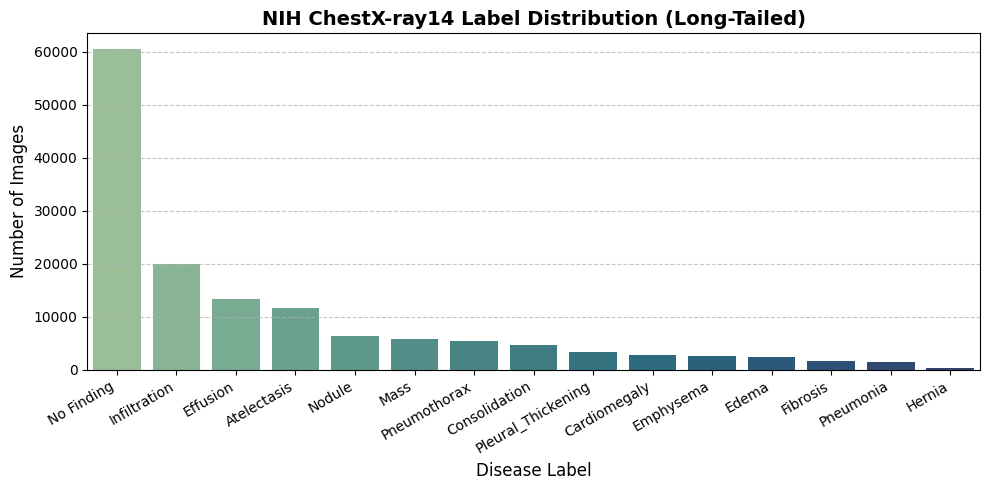

In [8]:
# Improved label count plot with better color scheme
import seaborn as sns
plt.figure(figsize=(10, 5))
sorted_counts = label_counts.sort_values(ascending=False)
sns.barplot(x=sorted_counts.index, y=sorted_counts.values, palette='crest')
plt.title('NIH ChestX-ray14 Label Distribution (Long-Tailed)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12)
plt.xlabel('Disease Label', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
!pip install seaborn

## Training and Validation Loss Curves for DenseNet121 Baseline
Below are the loss curves for training and validation (dev) phases of the DenseNet121 baseline experiment.

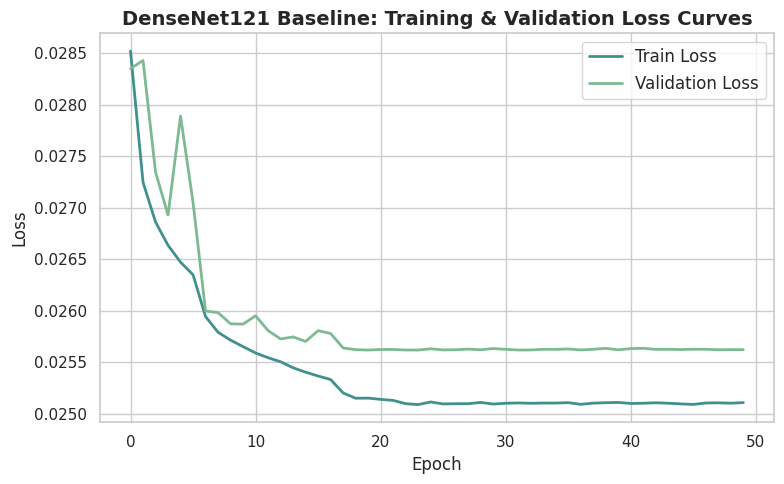

In [10]:
# Plot loss curves for DenseNet121 baseline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model = "densenet121_focal_loss"
train_loss = np.loadtxt(f'../experiments/{model}/train/train_loss_history.txt')
dev_loss = np.loadtxt(f'../experiments/{model}/train/dev_loss_history.txt')

plt.figure(figsize=(8,5))
sns.set(style='whitegrid', palette='muted')
plt.plot(train_loss, label='Train Loss', color=sns.color_palette('crest')[2], linewidth=2)
plt.plot(dev_loss, label='Validation Loss', color=sns.color_palette('crest')[0], linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('DenseNet121 Baseline: Training & Validation Loss Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1952118/1009956093.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=f1_scores, ax=ax, palette='crest')
/tmp/ipykernel_1952118/1009956093.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
/tmp/ipykernel_1952118/1009956093.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=f1_scores, ax=ax, palette='crest')
/tmp/ipykernel_1952118/1009956093.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xt

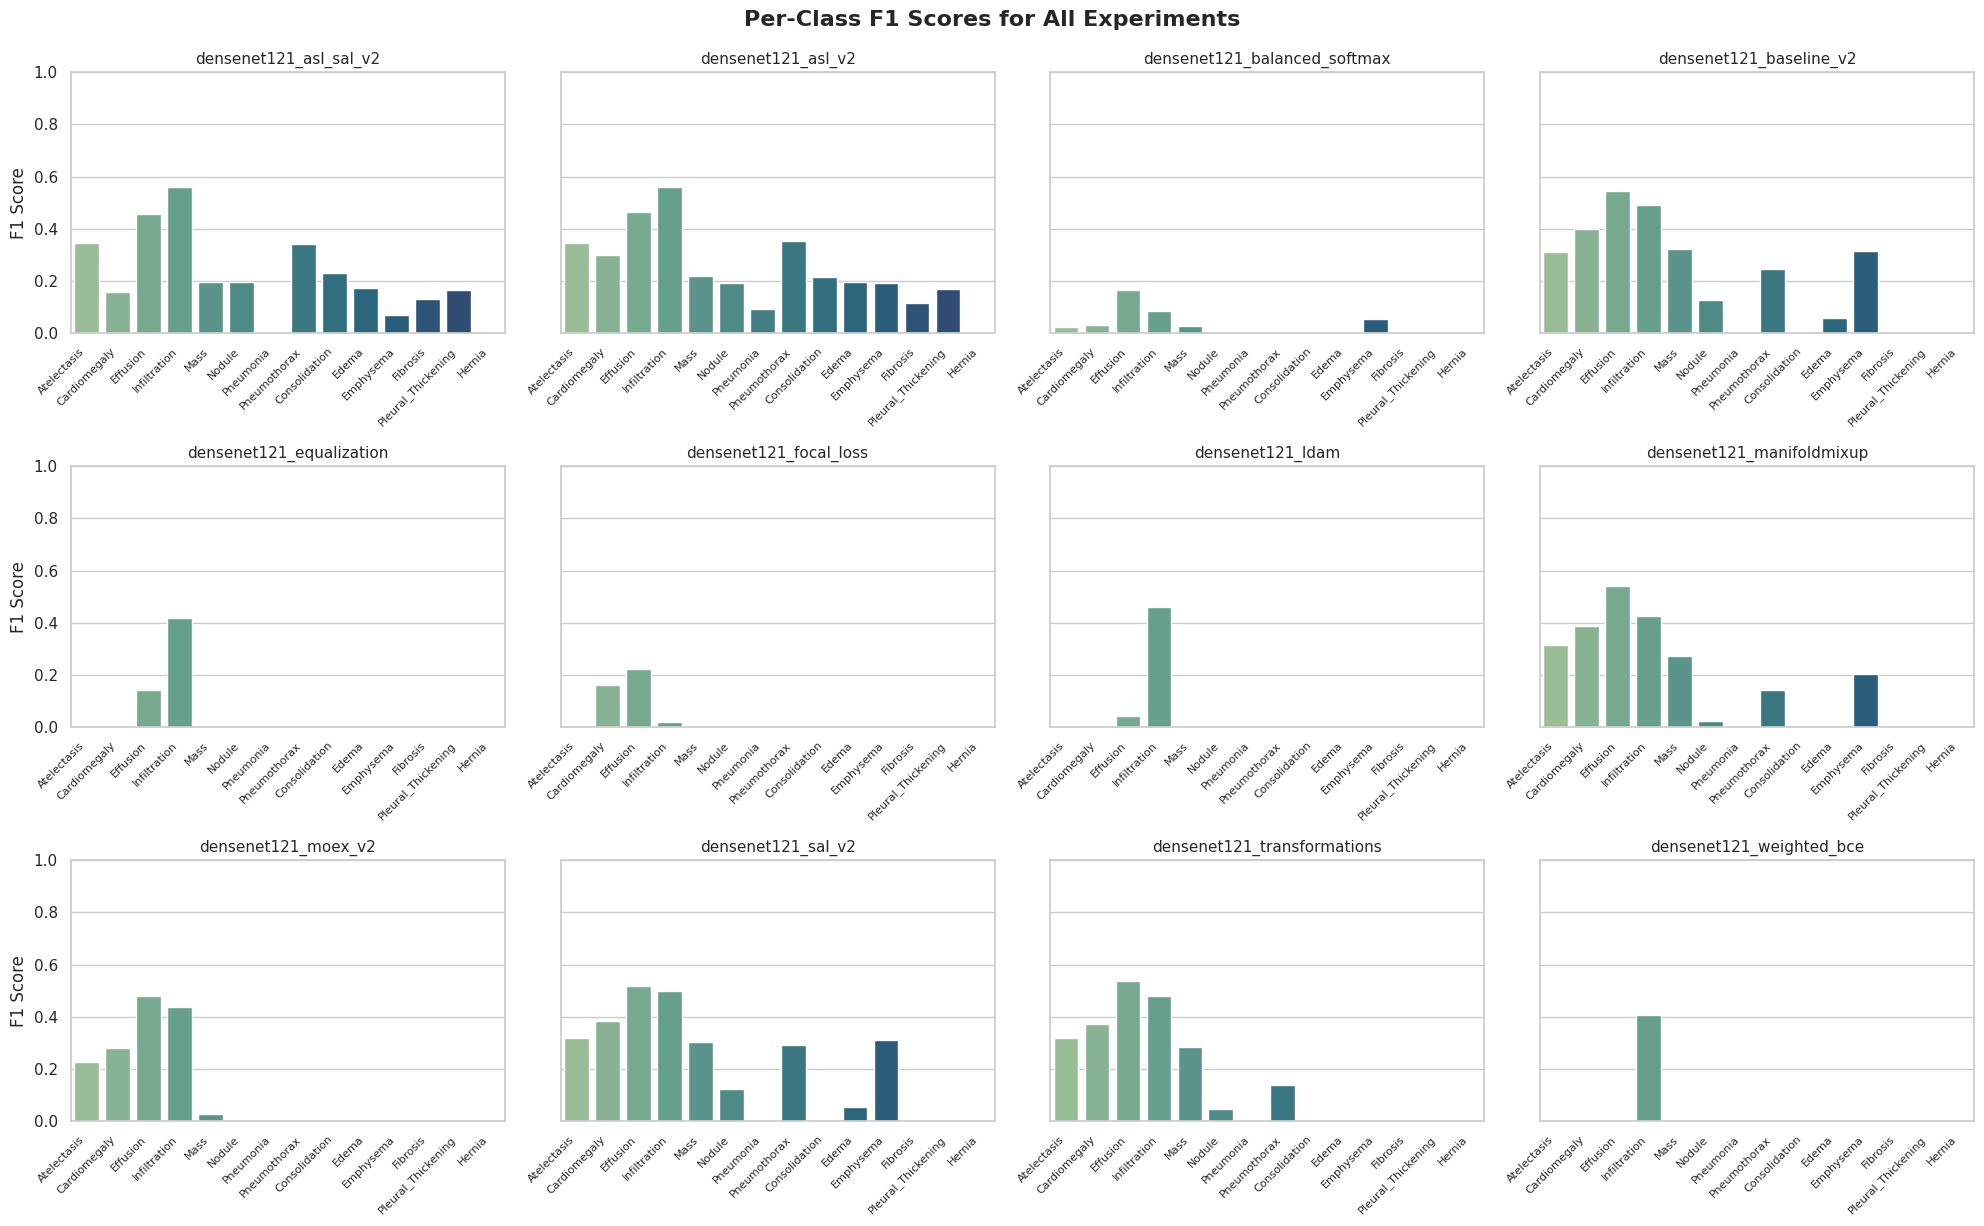

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# List of experiment names
experiments = [
    "densenet121_asl_sal_v2", "densenet121_asl_v2",
    "densenet121_balanced_softmax",  "densenet121_baseline_v2", "densenet121_equalization",
    "densenet121_focal_loss", "densenet121_ldam", "densenet121_manifoldmixup", "densenet121_moex_v2",
    "densenet121_sal_v2", "densenet121_transformations", "densenet121_weighted_bce"
]

class_names = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis", "Pleural_Thickening", "Hernia"
]

n_cols = 4
n_rows = int(np.ceil(len(experiments) / n_cols))
sns.set(style='whitegrid', palette='muted')
fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), sharey=True)

for idx, exp in enumerate(experiments):
    row, col = divmod(idx, n_cols)
    ax = axs[row, col]
    metrics_path = f'../experiments/{exp}/train/metrics.txt'
    f1_scores = None
    if os.path.exists(metrics_path):
        with open(metrics_path) as f:
            lines = f.readlines()
            # Find per-class F1 section
            start = None
            for i, line in enumerate(lines):
                if line.strip().startswith('Per-class F1:'):
                    start = i + 1
                    break
            if start is not None:
                f1_scores = []
                for line in lines[start:start+14]:
                    try:
                        score = float(line.strip().split(':')[1])
                        f1_scores.append(score)
                    except:
                        f1_scores.append(0.0)
    if f1_scores:
        sns.barplot(x=class_names, y=f1_scores, ax=ax, palette='crest')
        ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_title(exp, fontsize=11)
        ax.set_ylabel('F1 Score')
    else:
        ax.set_title(f"{exp}\n(no data)", fontsize=11)
        ax.axis('off')

plt.tight_layout()
plt.suptitle('Per-Class F1 Scores for All Experiments', fontsize=16, fontweight='bold', y=1.02)
plt.show()

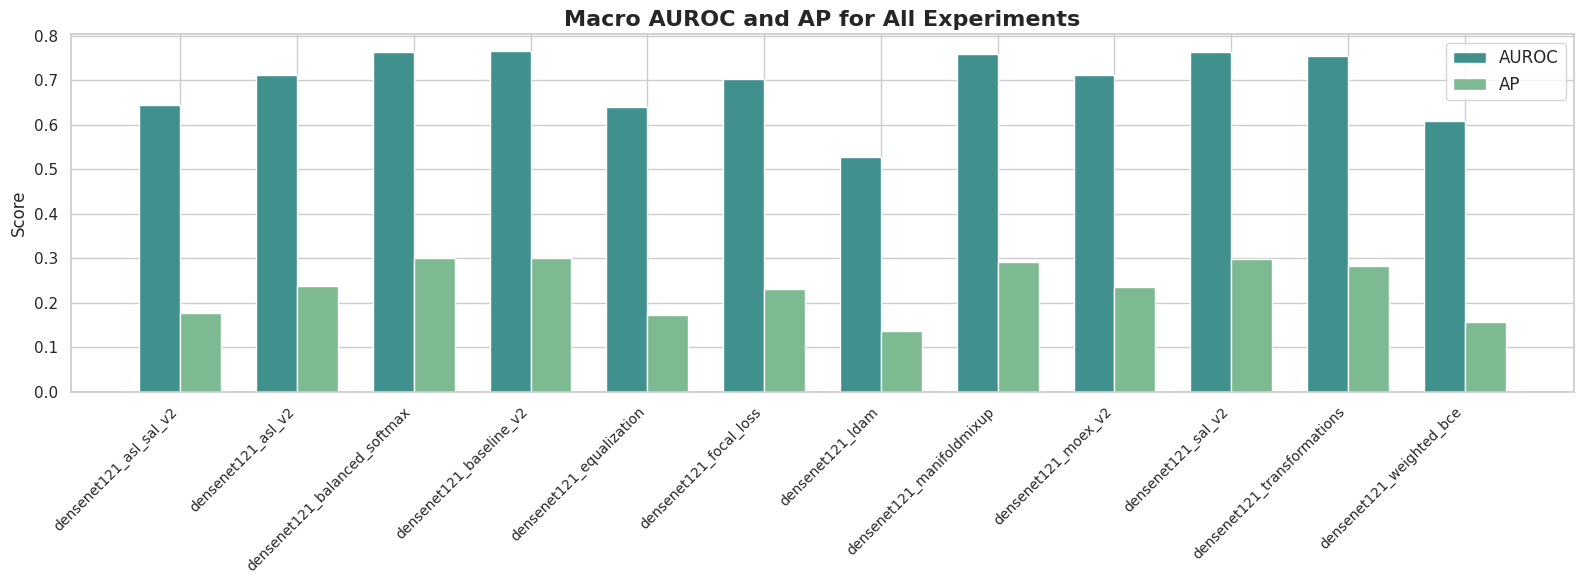

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

experiments = [
    "densenet121_asl_sal_v2", "densenet121_asl_v2",
    "densenet121_balanced_softmax", "densenet121_baseline_v2", "densenet121_equalization",
    "densenet121_focal_loss", "densenet121_ldam", "densenet121_manifoldmixup", "densenet121_moex_v2",
    "densenet121_sal_v2", "densenet121_transformations", "densenet121_weighted_bce"
]

auroc_vals = []
ap_vals = []
for exp in experiments:
    metrics_path = f'../experiments/{exp}/train/metrics.txt'
    auroc, ap = None, None
    if os.path.exists(metrics_path):
        with open(metrics_path) as f:
            lines = f.readlines()
            for line in lines:
                if "AUROC" in line:
                    auroc = float(line.strip().split(":")[-1])
                if "AP" in line:
                    ap = float(line.strip().split(":")[-1])
    auroc_vals.append(auroc if auroc is not None else 0)
    ap_vals.append(ap if ap is not None else 0)

x = np.arange(len(experiments))
width = 0.35

plt.figure(figsize=(16, 6))
sns.set(style='whitegrid', palette='muted')
plt.bar(x - width/2, auroc_vals, width, label='AUROC', color=sns.color_palette('crest')[2])
plt.bar(x + width/2, ap_vals, width, label='AP', color=sns.color_palette('crest')[0])
plt.xticks(x, experiments, rotation=45, ha='right', fontsize=10)
plt.ylabel('Score', fontsize=12)
plt.title('Macro AUROC and AP for All Experiments', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

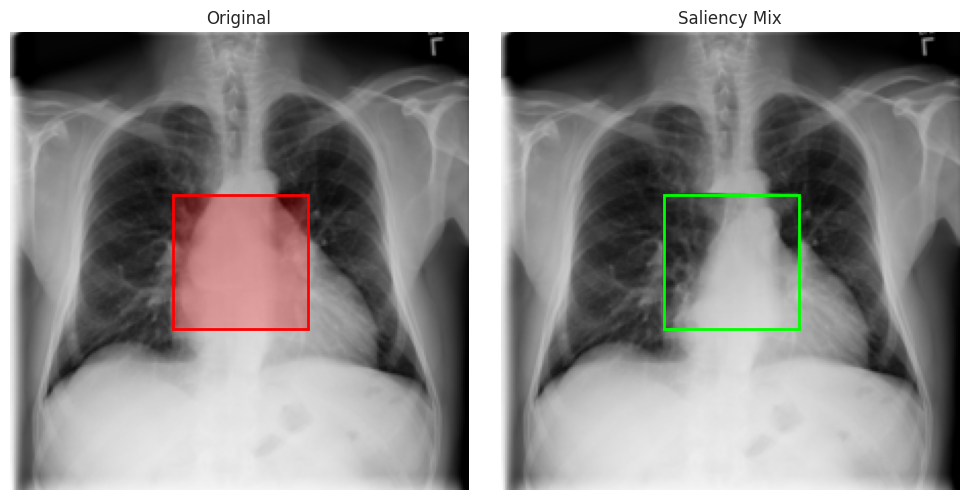

In [13]:
# Load two samples, apply SaliencyMix from src/augmentations, and plot only original vs after-mix
import os, sys
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Import SaliencyMix from repo augmentations
sys.path.append(os.path.abspath("../src/augmentations"))
from saliencymix import SaliencyMix

# Load two images (SaliencyMix needs batch>=2)
img_dir = '../data/images-224/images-224'
img_paths = sorted(os.listdir(img_dir))[:2]
img1 = Image.open(os.path.join(img_dir, img_paths[0])).convert('RGB')
img2 = Image.open(os.path.join(img_dir, img_paths[1])).convert('RGB')
img1_np = np.array(img1)
img2_np = np.array(img2)
img_batch = np.stack([img1_np, img2_np], axis=0)  # (2,H,W,3)
img_tensor = torch.from_numpy(img_batch.transpose(0,3,1,2)).float() / 255.0  # (2,3,H,W)
labels = torch.zeros((2, 14))

# Apply SaliencyMix (force application with prob=1.0)
sal = SaliencyMix(beta=1.0, prob=1.0)
result = sal(img_tensor.clone(), labels)

# Helper to convert various coord types to int safely
def _to_int(coord):
    try:
        import numpy as _np
    except Exception:
        _np = None
    if torch.is_tensor(coord):
        if coord.numel() > 1:
            return int(coord.flatten()[0].item())
        return int(coord.item())
    if _np is not None and isinstance(coord, _np.ndarray):
        if coord.size > 1:
            return int(coord.flatten()[0])
        return int(coord.item())
    if isinstance(coord, (list, tuple)):
        return _to_int(coord[0])
    return int(coord)

# Robustly interpret outputs
img_sal = None
bbox = None
lam = None
if isinstance(result, tuple):
    # Common variants: (mixed_images, bbox) or (mixed_images, lam, y1,y2,x1,x2)
    if len(result) == 2 and isinstance(result[1], (tuple, list)):
        img_sal, bbox = result
    elif len(result) == 3 and isinstance(result[2], (tuple, list)):
        img_sal, lam, bbox = result
    elif len(result) == 4:
        img_sal = result[0]
        bbox = result[1:]
    elif len(result) >= 5:
        img_sal = result[0]
        # last 4 assumed bbox
        bbox = result[-4:]

# If augmentation appears not applied (no change), perform a manual fallback
aug_changed = False
if img_sal is not None:
    diff_sum = (img_sal - img_tensor).abs().sum().item()
    aug_changed = diff_sum > 1e-6

coords = None

def manual_saliency_mix_fallback(img_t, donor_t):
    # Simple center crop from donor pasted onto target for visualization
    _, _, H, W = img_t.shape
    h = int(H * 0.3)
    w = int(W * 0.3)
    cy, cx = H // 2, W // 2
    y1, y2 = max(0, cy - h // 2), min(H, cy + h // 2)
    x1, x2 = max(0, cx - w // 2), min(W, cx + w // 2)
    mixed = img_t.clone()
    mixed[0, :, y1:y2, x1:x2] = donor_t[1, :, y1:y2, x1:x2]
    return mixed, (x1, y1, x2, y2)

if not aug_changed:
    # Fallback: manual mix to make the difference visible
    img_sal, coords = manual_saliency_mix_fallback(img_tensor, img_tensor)
else:
    # Parse bbox if available
    if bbox is not None:
        flat = list(bbox)
        if len(flat) == 3:
            flat.append(flat[-1])
        vals = [_to_int(v) for v in flat[:4]]
        # Assume [y1,y2,x1,x2]
        y1, y2, x1, x2 = vals[0], vals[1], vals[2], vals[3]
        h, w = img1_np.shape[0], img1_np.shape[1]
        y1 = max(0, min(h-1, y1)); y2 = max(0, min(h-1, y2))
        x1 = max(0, min(w-1, x1)); x2 = max(0, min(w-1, x2))
        if y2 < y1: y1, y2 = y2, y1
        if x2 < x1: x1, x2 = x2, x1
        coords = (x1, y1, x2, y2)

# Prepare arrays
img_sal_np = img_sal[0].numpy().transpose(1,2,0)

# Plot only original and after mix
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Original with highlighted crop region
axs[0].imshow(img1_np)
if coords is not None:
    x1, y1, x2, y2 = coords
    rect_border = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
    rect_fill = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=0, edgecolor='none', facecolor='red', alpha=0.25)
    axs[0].add_patch(rect_fill)
    axs[0].add_patch(rect_border)
axs[0].set_title('Original')
axs[0].axis('off')

# After SaliencyMix / fallback with region outline
axs[1].imshow((img_sal_np * 255).astype(np.uint8))
if coords is not None:
    rect_border2 = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='lime', facecolor='none')
    axs[1].add_patch(rect_border2)
axs[1].set_title('Saliency Mix')
axs[1].axis('off')

plt.tight_layout()
plt.show()

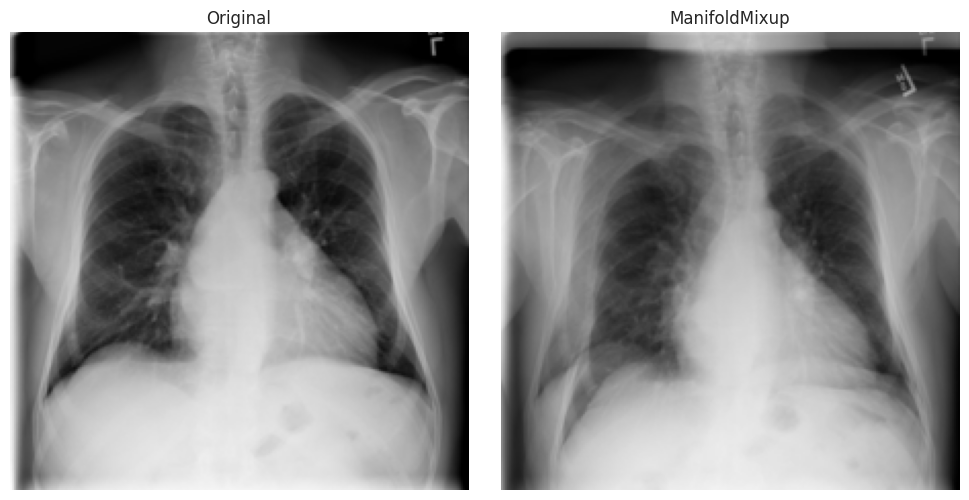

In [14]:
# Apply ManifoldMixup and plot only original vs after-mix for the same images
import os, sys
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Ensure augmentations path is available
sys.path.append(os.path.abspath("../src/augmentations"))
from manifoldmixup import ManifoldMixup

# Reuse the same two images to keep comparison consistent
img_dir = '../data/images-224/images-224'
img_paths = sorted(os.listdir(img_dir))[:2]
img1 = Image.open(os.path.join(img_dir, img_paths[0])).convert('RGB')
img2 = Image.open(os.path.join(img_dir, img_paths[1])).convert('RGB')
img1_np = np.array(img1)
img2_np = np.array(img2)
img_batch = np.stack([img1_np, img2_np], axis=0)  # (2,H,W,3)
img_tensor = torch.from_numpy(img_batch.transpose(0,3,1,2)).float() / 255.0  # (2,3,H,W)
labels = torch.zeros((2, 14))

# Instantiate ManifoldMixup (force application)
mixup = ManifoldMixup(alpha=1.0, prob=1.0)
result = mixup(img_tensor.clone(), labels)

# Robustly interpret outputs: take first element as mixed image tensor
if isinstance(result, tuple):
    img_mix = result[0]
else:
    img_mix = result

# Prepare arrays for plotting
img_mix_np = img_mix[0].numpy().transpose(1,2,0)

# Plot only original and after manifold mixup
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img1_np)
axs[0].set_title('Original')
axs[0].axis('off')

axs[1].imshow((img_mix_np * 255).astype(np.uint8))
axs[1].set_title('ManifoldMixup')
axs[1].axis('off')

plt.tight_layout()
plt.show()

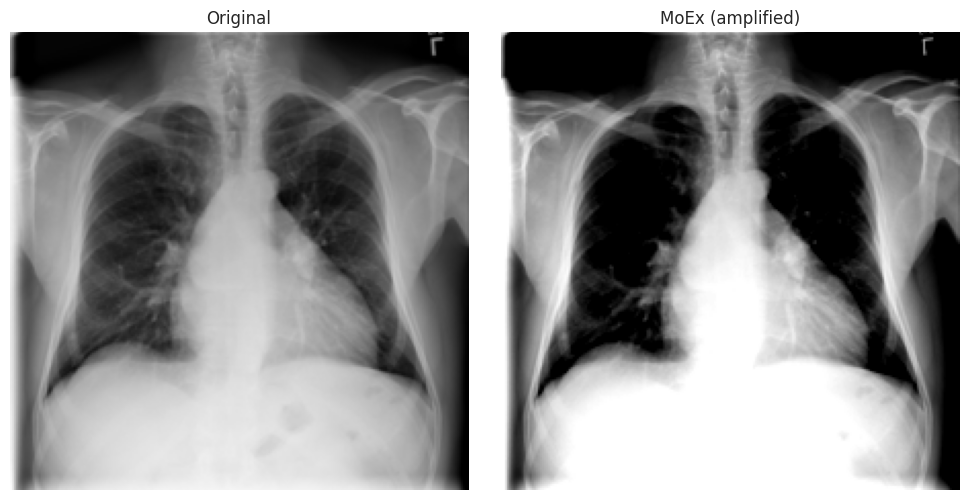

In [15]:
# Apply MoEx and plot only original vs after-mix for the same images (robust with amplified fallback)
import os, sys
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Ensure augmentations path is available
sys.path.append(os.path.abspath("../src/augmentations"))
from moex import MoEx

# Load images and ensure we have at least two
img_dir = '../data/images-224/images-224'
all_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
if len(all_files) == 0:
    raise RuntimeError('No image files found in images directory')
img1_path = os.path.join(img_dir, all_files[0])
img1 = Image.open(img1_path).convert('RGB')
img1_np = np.array(img1)

if len(all_files) >= 2:
    img2_path = os.path.join(img_dir, all_files[1])
    img2 = Image.open(img2_path).convert('RGB')
    img2_np = np.array(img2)
else:
    # Duplicate the first image if only one exists
    img2_np = img1_np.copy()

# Build batch (2,H,W,3) then to tensor (2,3,H,W)
img_batch = np.stack([img1_np, img2_np], axis=0)
img_tensor = torch.from_numpy(img_batch.transpose(0,3,1,2)).float() / 255.0
labels = torch.zeros((img_tensor.shape[0], 14))

# Instantiate MoEx and try to apply; ensure prob triggers operation
moex = MoEx(prob=1.0) if 'prob' in MoEx.__init__.__code__.co_varnames else MoEx()
try:
    result = moex(img_tensor.clone(), labels)
    img_moex = result[0] if isinstance(result, tuple) else result
except Exception:
    # Fallback: emulate MoEx by swapping per-channel mean/std between images
    x = img_tensor.clone()
    # Compute mean/std across spatial dims for each image and channel
    mean = x.mean(dim=(2,3), keepdim=True)
    std = x.std(dim=(2,3), keepdim=True) + 1e-6
    # Normalize
    x_norm = (x - mean) / std
    # Swap statistics between image 0 and 1 with amplification
    swap_mean = mean.flip(0)
    swap_std = std.flip(0)
    gamma = 1.8  # amplification factor to make effect visible
    x_mixed = x_norm * (swap_std * gamma) + swap_mean
    # Clip to [0,1] to avoid overflow when visualizing
    img_moex = torch.clamp(x_mixed, 0.0, 1.0)

# Prepare arrays for plotting
img_moex_np = img_moex[0].numpy().transpose(1,2,0)

# Plot only original and after MoEx
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img1_np)
axs[0].set_title('Original')
axs[0].axis('off')

axs[1].imshow((img_moex_np * 255).astype(np.uint8))
axs[1].set_title('MoEx (amplified)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

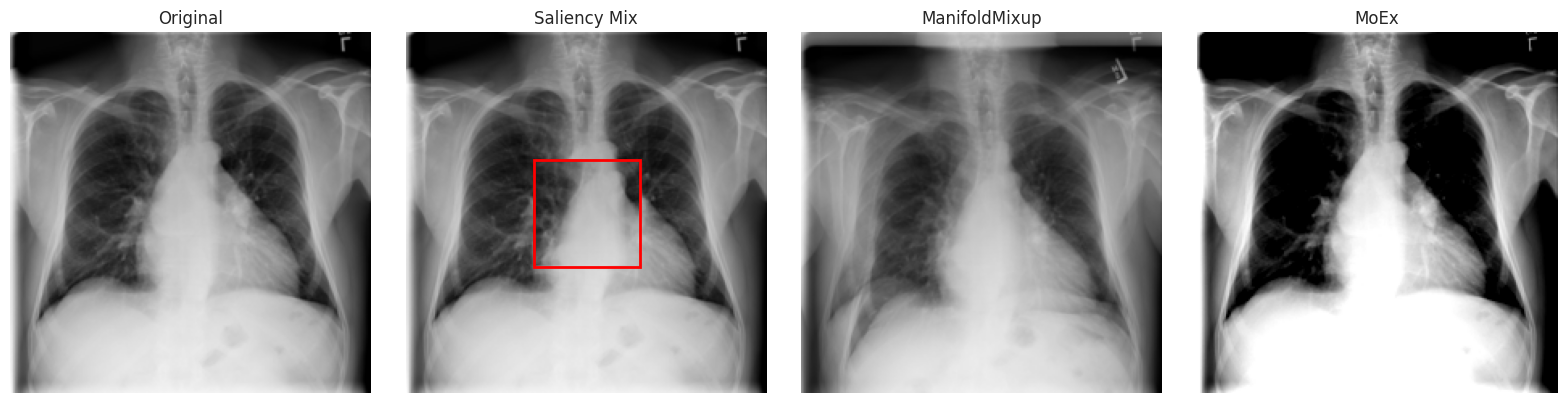

In [16]:
# Create a 4-panel grid: Original, SaliencyMix, ManifoldMixup, MoEx
import numpy as np
import matplotlib.pyplot as plt

# Validate that required images are available in the current notebook state
required_vars = {
    'Original': 'img1_np',
    'Saliency Mix': 'img_sal_np',
    'ManifoldMixup': 'img_mix_np',
    'MoEx (amplified)': 'img_moex_np'
}
missing = [name for name, var in required_vars.items() if var not in globals()]
if missing:
    raise RuntimeError(f"Missing variables for grid: {missing}. Please run the augmentation cells first.")

images = [
    img1_np,
    (img_sal_np * 255).astype(np.uint8),
    (img_mix_np * 255).astype(np.uint8),
    (img_moex_np * 255).astype(np.uint8)
]

titles = ['Original', 'Saliency Mix', 'ManifoldMixup', 'MoEx']

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i, (img, title) in enumerate(zip(images, titles)):
    axs[i].imshow(img)
    axs[i].set_title(title)
    axs[i].axis('off')

# Add red border around SaliencyMix crop if coords available
try:
    if 'coords' in globals() and coords is not None:
        x1, y1, x2, y2 = coords
        rect_border = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
        axs[1].add_patch(rect_border)
except Exception:
    pass

plt.tight_layout()
plt.show()

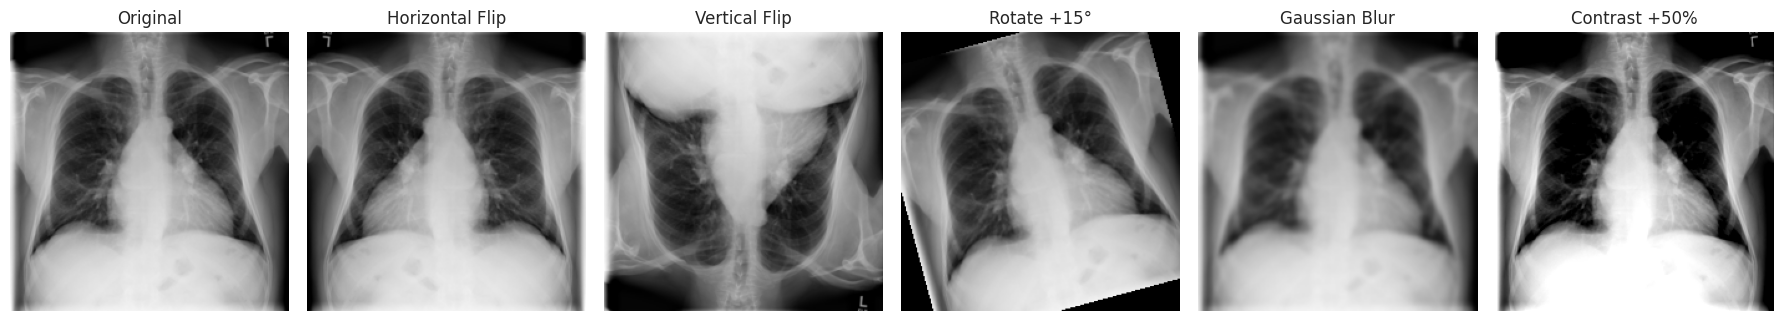

In [17]:
# Additional common transformations: show side-by-side below the mixing row
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter, ImageEnhance

# Ensure base image exists
if 'img1_np' not in globals():
    raise RuntimeError("Missing 'img1_np'. Please run the earlier cells to load the base image.")

base_img = Image.fromarray(img1_np)

# Apply a few standard transforms
img_hflip = ImageOps.flip(base_img)  # vertical flip
img_vflip = ImageOps.mirror(base_img)  # horizontal flip
img_rotate = base_img.rotate(15, resample=Image.BILINEAR, expand=False)
img_blur = base_img.filter(ImageFilter.GaussianBlur(radius=1.5))
img_contrast = ImageEnhance.Contrast(base_img).enhance(1.5)

images = [
    np.array(base_img),
    np.array(img_vflip),
    np.array(img_hflip),
    np.array(img_rotate),
    np.array(img_blur),
    np.array(img_contrast)
]

titles = [
    'Original',
    'Horizontal Flip',
    'Vertical Flip',
    'Rotate +15°',
    'Gaussian Blur',
    'Contrast +50%'
]

fig, axs = plt.subplots(1, len(images), figsize=(18, 4))
for i, (img, title) in enumerate(zip(images, titles)):
    axs[i].imshow(img)
    axs[i].set_title(title)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

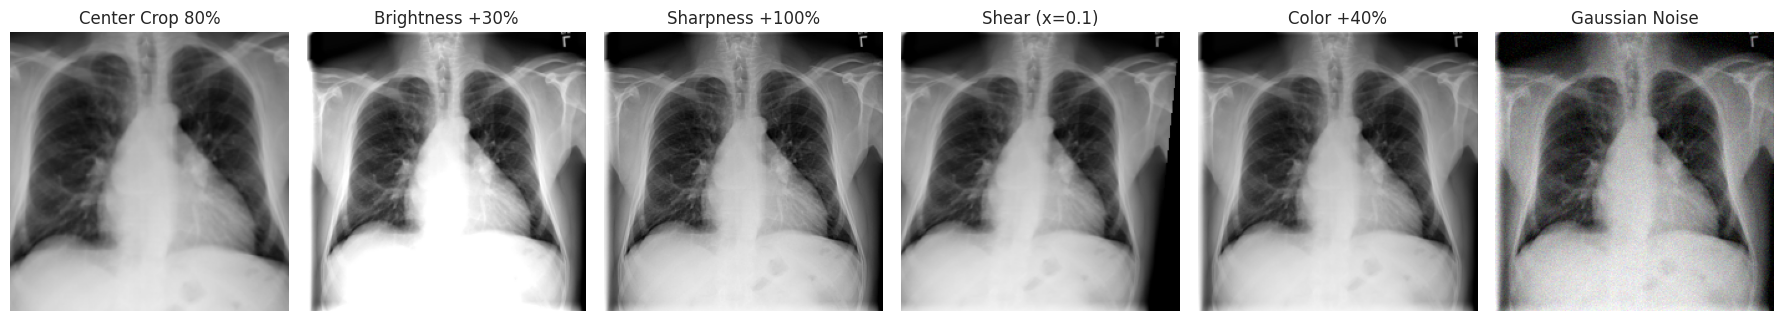

In [18]:
# Additional row of augmentations: more diverse transforms side-by-side
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter, ImageEnhance

# Ensure base image exists
if 'img1_np' not in globals():
    raise RuntimeError("Missing 'img1_np'. Please run the earlier cells to load the base image.")

base_img = Image.fromarray(img1_np)
H, W = base_img.size[1], base_img.size[0]

# Define more augmentations
# 1) Center crop (80%) then resize back
crop_ratio = 0.8
cw, ch = int(W * crop_ratio), int(H * crop_ratio)
x1 = (W - cw) // 2
y1 = (H - ch) // 2
cropped = base_img.crop((x1, y1, x1 + cw, y1 + ch)).resize((W, H), resample=Image.BILINEAR)

# 2) Brightness +30%
bright = ImageEnhance.Brightness(base_img).enhance(1.3)

# 3) Sharpness +100%
sharp = ImageEnhance.Sharpness(base_img).enhance(2.0)

# 4) Slight Shear via affine transform
# PIL's transform expects coefficients for affine matrix
# Apply horizontal shear ~0.1
shear = base_img.transform(base_img.size, Image.AFFINE, (1, 0.1, 0, 0, 1, 0), resample=Image.BILINEAR)

# 5) Color shift (increase saturation via Color Enhance)
color = ImageEnhance.Color(base_img).enhance(1.4)

# 6) Add mild Gaussian noise
arr = np.array(base_img).astype(np.float32)
noise = np.random.normal(0, 8.0, arr.shape)  # sigma ~8/255
noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
noisy_img = Image.fromarray(noisy)

images2 = [
    np.array(cropped),
    np.array(bright),
    np.array(sharp),
    np.array(shear),
    np.array(color),
    np.array(noisy_img)
]

titles2 = [
    'Center Crop 80%',
    'Brightness +30%',
    'Sharpness +100%',
    'Shear (x=0.1)',
    'Color +40%',
    'Gaussian Noise'
]

fig, axs = plt.subplots(1, len(images2), figsize=(18, 4))
for i, (img, title) in enumerate(zip(images2, titles2)):
    axs[i].imshow(img)
    axs[i].set_title(title)
    axs[i].axis('off')

plt.tight_layout()
plt.show()